# 설문 기반 RFM 세그먼트 분석

---

## 분석 개요

`05_segmentation`을 **SQL 중심 워크플로**로 구성한 분석이다. 추출·점수화·분류·집계 등 분석 로직을 노트북 셀이 아니라 **한 개의 SQL 파일** `../sql/05_segmentation.sql`에 모으고, 각 쿼리를 `-- name:` 마커로 구분한다. 노트북은 쿼리를 이름으로 호출해 **시각화·해석만** 담당한다. 현업 분석 환경(웨어하우스 + dbt/analytics-engineering)의 역할 분담을 모사한 구조다.

| 구분 | 위치 | 역할 |
|------|------|------|
| 데이터 추출·점수·분류·집계 | `../sql/05_segmentation.sql` | `-- name:` 마커로 구분된 10개 쿼리 (CASE WHEN · JOIN · CTE · 윈도우 · RANK · VIEW · PK/FK) |
| 시각화·해석 | 이 노트북 | `Q["쿼리이름"]`으로 호출 → Plotly + 결과 마크다운 |

- 분석 대상: 플랫폼 사용자 200명 / 구매자 191명 (모수 정의는 `docs/variables.md`)
- ⚠️ **데이터 한계**: 횡단면 자기보고 설문이며, M(객단가)·구매 빈도는 실제 거래 로그가 아니다. 세그먼트는 확정 고객 가치가 아니라 **룰 기반 구매 활동 프로파일링**으로 해석한다.


In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
# .env는 프로젝트 루트에 있다
load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# 분석 로직은 한 SQL 파일에 모으고, `-- name:` 마커로 쿼리를 구분한다.
# 노트북은 단일 SQL 파일의 쿼리를 이름으로 호출한다.
import re

SQL_FILE = Path('../sql/05_segmentation.sql')

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리} 딕셔너리로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)
print('로드된 쿼리:', list(Q))

def run(name):
    """이름으로 SELECT 쿼리를 실행해 DataFrame을 반환한다."""
    return pd.read_sql(Q[name], engine)

def execute(name):
    """이름으로 DDL(세미콜론 구분 다중 구문)을 실행한다 — 뷰·테이블 생성용."""
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

로드된 쿼리: ['rfm_scored_view', 'rfm_seg_table', 'rfm_distribution', 'segment_counts', 'segment_profile', 'segment_gender', 'segment_age', 'potential_split', 'potential_profile', 'cant_lose']


In [3]:
SEGMENT_ORDER = ['Champions', 'Loyal', 'Potential', 'At Risk', 'Hibernating']
SEGMENT_COLORS = {'Champions': '#10B981', 'Loyal': '#3B82F6', 'Potential': '#F59E0B',
                  'At Risk': '#EF4444', 'Hibernating': '#94A3B8'}
SEGMENT_EMOJI = {'Champions': '🏆', 'Loyal': '💎', 'Potential': '🌱',
                 'At Risk': '⚠️', 'Hibernating': '💤'}
R_LABEL = {1: '6개월 이상', 2: '3-6개월', 3: '1-3개월', 4: '1개월 이내'}
F_LABEL = {1: '1-2번', 2: '3-5번', 3: '6번 이상'}
M_LABEL = {1: '3만원 미만', 2: '3-7만원', 3: '7-15만원', 4: '15-30만원', 5: '30만원 이상'}
SUB_ORDER = ['Active × High M', 'Active × Low M', 'Light × High M', 'Light × Low M']
QUAD_COLORS = ['#10B981', '#3B82F6', '#F59E0B', '#94A3B8']
AGE3_ORDER = ['10-20대 초중반', '20대 후반', '30대 이상']
AGE_COLORS = {'10-20대 초중반': '#FCA5A5', '20대 후반': '#F59E0B', '30대 이상': '#60A5FA'}

---

## 0. SQL 파이프라인 구축

- `Q["rfm_scored_view"]` — 설문 응답을 R·F·M 점수와 5세그먼트로 변환하는 뷰(`rfm_scored`). 비즈니스 로직(CASE WHEN 분류)을 SQL에 둔다.
- `Q["rfm_seg_table"]` — 구매자(191명)만 영구 테이블(`rfm_seg`)로 저장하고 `user_id`에 PK + survey 참조 FK를 건다.


In [4]:
# 점수·분류 뷰 → 구매자 매핑 테이블(PK+FK) 순으로 SQL 파이프라인 실행
execute('rfm_scored_view')
execute('rfm_seg_table')

n_users  = pd.read_sql('SELECT COUNT(*) AS n FROM rfm_scored', engine).iloc[0, 0]
n_buyers = pd.read_sql('SELECT COUNT(*) AS n FROM rfm_seg', engine).iloc[0, 0]
print(f'플랫폼 사용자(rfm_scored): {n_users}명')
print(f'구매자(rfm_seg): {n_buyers}명')

assert (n_users, n_buyers) == (200, 191), (
    f'모수가 200/191이 아니다 (현재 {n_users}/{n_buyers}). '
    '01_cleaning.ipynb로 survey 테이블을 먼저 적재하라.'
)

플랫폼 사용자(rfm_scored): 200명
구매자(rfm_seg): 191명


---

## 데이터 로딩 — Score 매핑 근거

설문 답변(범주형)을 정수 점수로 매핑한다. 매핑 원칙: **값↑ = 최근성·빈도·객단가 신호↑** (값이 클수록 더 최근·자주·객단가가 상대적으로 높은 신호로 해석함).

### RFM Score 매핑

| 차원 | 설문 문항 | 1점 | 2점 | 3점 | 4점 | 5점 |
|---|---|---|---|---|---|---|
| **R (Recency)** | Q10. 최근 구매 시점 | 6개월 이상 | 3~6개월 | 1~3개월 | **1개월 이내** | — |
| **F (Frequency)** | Q9. 6개월 구매 횟수 | 1~2번 | 3~5번 | **6번 이상** | — | — |
| **M (Monetary)** | Q11. 1회 객단가 | 3만원 미만 | 3~7만원 | 7~15만원 | 15~30만원 | **30만원 이상** |

**NPS 세그먼트 (Q15. 추천 의향 0-10, 표준 기준)**: 0-6 Detractor · 7-8 Passive · 9-10 Promoter

> ⚠️ **단계 수가 변수마다 다른 이유**: 설문 원본 선택지 수를 그대로 따름 (R=4 / F=3 / M=5). NTILE 분위 스코어링은 순서형 범주에서 불안정하므로 적용 X.

---


---

## 1. R·F·M 변수 분포
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? (F)
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? (R)
- Q11. 패션 플랫폼에서 한 번 구매할 때 평균 지출 금액은 얼마인가요? (M)

---

**분석 질문 1** — 구매자의 최근성·빈도·객단가는 어떻게 분포하는가?

- 분석 대상: 구매자 191명
- 분석 방법: R·F·M 점수별 응답자 수와 비율 확인(기술통계)
- 해석 기준: 특정 점수대에 응답자가 과도하게 몰리거나 희소한지 확인해, 이후 세그먼트 룰이 과분할되지 않는지 점검한다.


In [5]:
# 분포 집계는 SQL에서 (rfm_distribution — UNION ALL + GROUP BY + 윈도우 비율)
rfm_dist = run('rfm_distribution')
rfm_dist

,dim,score,n,pct
0,F (Frequency),1,61,31.9
1,F (Frequency),2,71,37.2
2,F (Frequency),3,59,30.9
3,M (Monetary),1,16,8.4
4,M (Monetary),2,87,45.5
5,M (Monetary),3,65,34.0
6,M (Monetary),4,21,11.0
7,M (Monetary),5,2,1.0
8,R (Recency),1,6,3.1
9,R (Recency),2,24,12.6


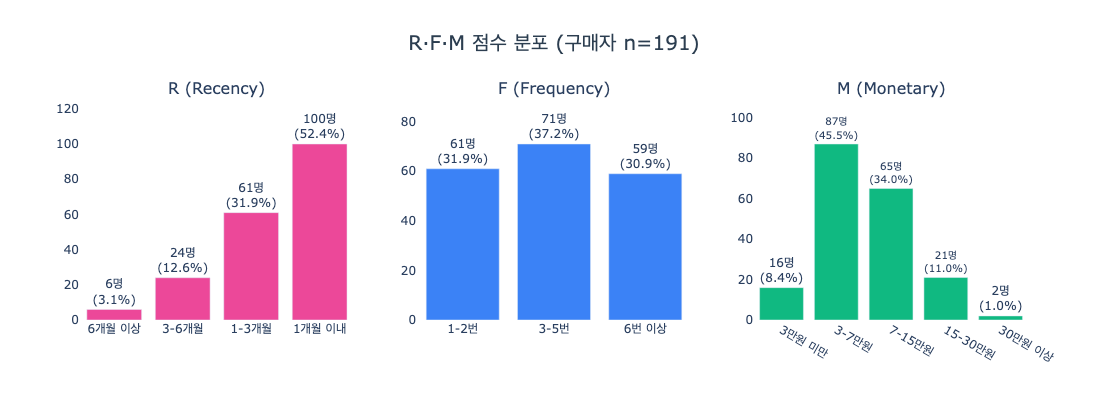

In [6]:
fig = make_subplots(rows=1, cols=3, subplot_titles=('R (Recency)', 'F (Frequency)', 'M (Monetary)'))

for col, (label, dim, color) in enumerate([
    (R_LABEL, 'R (Recency)',   '#EC4899'),
    (F_LABEL, 'F (Frequency)', '#3B82F6'),
    (M_LABEL, 'M (Monetary)',  '#10B981'),
], start=1):
    sub = rfm_dist[rfm_dist['dim'] == dim].sort_values('score')
    fig.add_trace(go.Bar(
        x=[label[int(s)] for s in sub['score']],
        y=sub['n'],
        marker_color=color,
        text=[f'{int(n)}명<br>({p:.1f}%)' for n, p in zip(sub['n'], sub['pct'])],
        textposition='outside',
        showlegend=False,
    ), row=1, col=col)
    fig.update_yaxes(range=[0, sub['n'].max() * 1.25], row=1, col=col)

fig.update_layout(
    title=dict(text=f'R·F·M 점수 분포 (구매자 n={n_buyers})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', height=400, showlegend=False,
)
fig.show()

### 분석 질문 1 결과: R은 최근 구매자 쪽으로 몰리고, F·M은 세그먼트 분류 기준을 만든다
_사용 SQL: `rfm_distribution` — UNION ALL + GROUP BY + 윈도우 비율_


> ### 섹션 결론
> - **R (Recency)**: 1개월 이내 응답자가 **100명(52.4%)** 으로 가장 많아, 구매자 표본은 최근 구매 경험자 중심으로 구성되어 있다.
> - **F (Frequency)**: 1-2번 **61명(31.9%)** · 3-5번 **71명(37.2%)** · 6번 이상 **59명(30.9%)** 으로 비교적 고르게 나뉘어, 빈도 차이가 세그먼트 분류의 주요 기준 중 하나가 된다.
> - **M (Monetary)**: 3-7만원이 **87명(45.5%)** 으로 가장 많고, 15만원 이상은 **23명(12.0%)** 으로 적다. 따라서 객단가 상위 신호는 희소 구간으로 보고, M≥3(7만원 이상)을 상대적 객단가 신호로 사용한다.

---

## 2. 룰 기반 5세그먼트 분류
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? (F)
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? (R)
- Q11. 패션 플랫폼에서 한 번 구매할 때 평균 지출 금액은 얼마인가요? (M)

---

**분석 질문 2** — R·F·M 조합으로 구매자를 어떻게 나눌 수 있는가?

- 분석 대상: 구매자 191명
- 분석 방법: SQL `CASE WHEN` 기반 5세그먼트 룰 분류
- 해석 기준: 표준 RFM 11세그먼트처럼 세밀하게 쪼개기보다, 설문 표본 규모에서 설명 가능한 5개 그룹으로 압축한다.

**세그먼트별 RFM Score 매트릭스**

| 세그먼트 | R Score | F Score | M Score | 추가 조건 | 해석 |
|---------|---------|---------|---------|---------|------|
| 🏆 **Champions** | 3, 4 | 3 | 3, 4, 5 | — | 최근·자주·객단가가 상대적으로 높은 구매 활동층 |
| 💎 **Loyal** | 3, 4 | 3 | 1, 2 | Champions 제외 | 최근·자주 구매하지만 객단가는 낮은 층 |
| 🌱 **Potential** | 3, 4 | 1, 2 | 1-5 | — | 최근 구매는 있으나 빈도는 낮은 층 |
| ⚠️ **At Risk** | 1, 2 | — | — | F≥2 또는 M≥3 | 최근 구매 공백이 있으나 과거 빈도·객단가 신호가 남은 층 |
| 💤 **Hibernating** | 1, 2 | 1 | 1, 2 | At Risk 제외 | 최근성·빈도·객단가가 모두 낮은 층 |

> **읽는 법**: R/F/M 컬럼은 해당 세그먼트에 속하기 위해 가질 수 있는 Score 값이다. 예를 들어 Champions는 R=3 또는 4, F=3, M=3·4·5 중 하나를 모두 충족한다. At Risk는 R≤2 조건을 충족하면서 F 또는 M 중 하나라도 과거 빈도·객단가 신호가 남아 있는 경우다.

> **CASE WHEN 평가 순서**: SQL은 위에서 아래로 첫 번째 매칭되는 WHEN을 적용한다. 따라서 Loyal은 Champions 조건을 먼저 제외한 뒤 남는 `F=3·R≥3·M<3` 사용자로 해석한다.

**RFM 60개 조합 → 세그먼트 매핑 (R-F-M 3자리 코드)**

| 세그먼트 | 조합 수 | RFM 코드 |
|---------|---|----------|
| 🏆 **Champions** | 6 | `333, 334, 335, 433, 434, 435` |
| 💎 **Loyal** | 4 | `331, 332, 431, 432` |
| 🌱 **Potential** | 20 | `311, 312, 313, 314, 315, 321, 322, 323, 324, 325,` <br> `411, 412, 413, 414, 415, 421, 422, 423, 424, 425` |
| ⚠️ **At Risk** | 26 | `113, 114, 115, 121, 122, 123, 124, 125, 131, 132, 133, 134, 135,` <br> `213, 214, 215, 221, 222, 223, 224, 225, 231, 232, 233, 234, 235` |
| 💤 **Hibernating** | 4 | `111, 112, 211, 212` |
| **합계** | **60** | R(4) × F(3) × M(5) = 60 |

> **Champions M≥3 선택 사유**: M≥4로 잡으면 표본이 지나치게 작아져 해석이 불안정하다. M≥3은 `7만원 이상`으로, 설문 범주 안에서 상대적 객단가 신호를 유지하면서 분석 가능한 규모를 확보하는 기준이다.


In [7]:
# 세그먼트 인원·비율 집계 (segment_counts — GROUP BY + 윈도우 비율)
seg_counts = (
    run('segment_counts')
    .set_index('rfm_segment')
    .reindex(SEGMENT_ORDER)
    .reset_index()
)
print(f"합계: {int(seg_counts['n'].sum())}명")
seg_counts

합계: 191명


,rfm_segment,n,pct
0,Champions,28,14.7
1,Loyal,28,14.7
2,Potential,105,55.0
3,At Risk,19,9.9
4,Hibernating,11,5.8


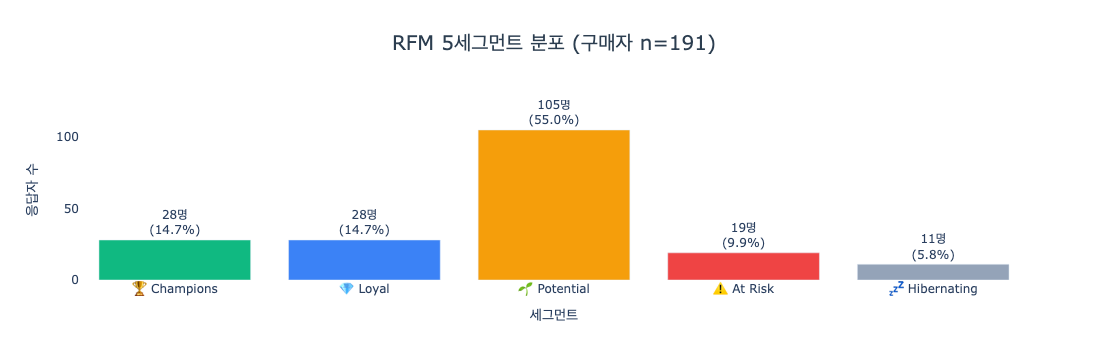

In [8]:
fig = go.Figure(go.Bar(
    x=[f"{SEGMENT_EMOJI[s]} {s}" for s in seg_counts['rfm_segment']],
    y=seg_counts['n'],
    marker_color=[SEGMENT_COLORS[s] for s in seg_counts['rfm_segment']],
    text=[f"{int(n)}명<br>({p:.1f}%)" for n, p in zip(seg_counts['n'], seg_counts['pct'])],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'RFM 5세그먼트 분포 (구매자 n={n_buyers})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='세그먼트', yaxis_title='응답자 수',
    yaxis=dict(range=[0, seg_counts['n'].max() * 1.2]), plot_bgcolor='white',
)
fig.show()

### 분석 질문 2 결과: Potential이 가장 크고, 구매 공백 그룹은 15%대
_사용 SQL: `segment_counts` — GROUP BY + 윈도우 비율_


> ### 섹션 결론
> - 표 기준으로 가장 큰 단일 세그먼트는 **Potential 105명(55.0%)** 이다. 최근 구매는 있으나 빈도가 낮은 층이 많아, 구매자 내부의 주요 차이는 단순 충성/이탈보다 **빈도 성장 여지**로 읽는 편이 자연스럽다.
> - **Champions 28명(14.7%) + Loyal 28명(14.7%)** 은 R·F 조건을 더 엄격하게 적용한 충성 구매 활동층이다. `04_retention_and_behavior`의 R×F `충성`보다 좁은 기준이므로 비율이 낮아지는 것이 자연스럽다.
> - **At Risk 19명(9.9%) + Hibernating 11명(5.8%) = 30명(15.7%)** 은 모두 3개월 초과 구매 공백 그룹이다. `04_retention_and_behavior`의 `재활성화 후보 + 휴면`과 같은 구매 공백 축을 공유하지만, `05_segmentation`에서는 M을 더해 At Risk 내부의 객단가 신호를 따로 확인한다.


---

## 3. 세그먼트 프로파일링
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? (F)
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? (R)
- Q11. 패션 플랫폼에서 한 번 구매할 때 평균 지출 금액은 얼마인가요? (M)
- Q15. 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요? (추천점수)
- Q1. 성별을 선택해주세요.
- Q2. 연령대를 선택해주세요.

---

**분석 질문 3** — RFM 세그먼트별 추천점수와 인구통계 특성은 어떻게 다른가?

- 분석 대상: 구매자 191명
- 분석 방법: SQL 윈도우 함수(`AVG/COUNT OVER (PARTITION BY rfm_segment)`)로 세그먼트별 평균·비율 집계
- 해석 기준: 세그먼트가 추천 의향과 같은 방향으로 움직이는지 확인하되, 인과나 예측 성능으로 해석하지 않는다.
- 참고: `AVG(AVG(nps)) OVER ()`는 세그먼트 평균의 단순 평균이라 크기가 큰 세그먼트를 반영하지 못한다. 따라서 원자료 기준 `AVG(nps) OVER ()`를 전체 평균으로 사용한다.


In [9]:
# 세그먼트 프로파일링 (segment_profile — JOIN + 윈도우 PARTITION BY / OVER())
profile = (
    run('segment_profile')
    .drop_duplicates(subset=['rfm_segment'])
    .set_index('rfm_segment').reindex(SEGMENT_ORDER).reset_index()
)
overall_nps = profile['overall_nps'].iloc[0]
profile

,rfm_segment,n,pct_of_total,avg_R,avg_F,avg_M,avg_nps,overall_nps,nps_vs_overall
0,Champions,28,14.7,3.82,3.00,3.18,7.39,6.55,0.84
1,Loyal,28,14.7,3.89,3.00,1.89,7.04,6.55,0.49
2,Potential,105,55.0,3.50,1.60,2.45,6.33,6.55,-0.22
3,At Risk,19,9.9,1.79,1.74,3.16,6.32,6.55,-0.23
4,Hibernating,11,5.8,1.82,1.00,1.82,5.64,6.55,-0.91


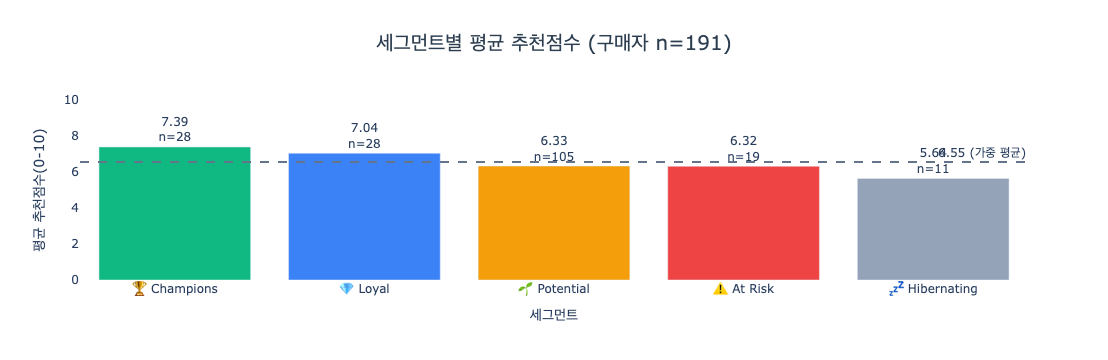

In [10]:
fig = go.Figure(go.Bar(
    x=[f"{SEGMENT_EMOJI[s]} {s}" for s in profile['rfm_segment']],
    y=profile['avg_nps'],
    marker_color=[SEGMENT_COLORS[s] for s in profile['rfm_segment']],
    text=[f'{score:.2f}<br>n={int(n)}' for score, n in zip(profile['avg_nps'], profile['n'])],
    textposition='outside',
))
fig.add_hline(y=overall_nps, line_dash='dash', line_color='#64748B',
              annotation_text=f'{overall_nps:.2f} (가중 평균)', annotation_position='top right')
fig.update_layout(
    title=dict(text=f'세그먼트별 평균 추천점수 (구매자 n={n_buyers})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='세그먼트', yaxis_title='평균 추천점수(0-10)',
    yaxis=dict(range=[0, 10]), plot_bgcolor='white',
)
fig.show()

In [11]:
# 인구통계 프로파일도 SQL에서 (segment_gender / segment_age — 조건부 집계)
g = run('segment_gender').set_index('rfm_segment').reindex(SEGMENT_ORDER)
demo = pd.DataFrame({'남성': g['male_n'], '여성': g['female_n']})

a = run('segment_age').set_index('rfm_segment').reindex(SEGMENT_ORDER)
age_only = pd.DataFrame({
    '10-20대 초중반': a['age_young'],
    '20대 후반':      a['age_mid'],
    '30대 이상':      a['age_old'],
})
display(demo)
display(age_only)

,남성,여성
rfm_segment,,
Champions,9.0,19.0
Loyal,3.0,25.0
Potential,47.0,58.0
At Risk,10.0,9.0
Hibernating,4.0,7.0


,10-20대 초중반,20대 후반,30대 이상
rfm_segment,,,
Champions,11.0,14.0,3.0
Loyal,16.0,8.0,4.0
Potential,41.0,33.0,31.0
At Risk,7.0,10.0,2.0
Hibernating,5.0,3.0,3.0


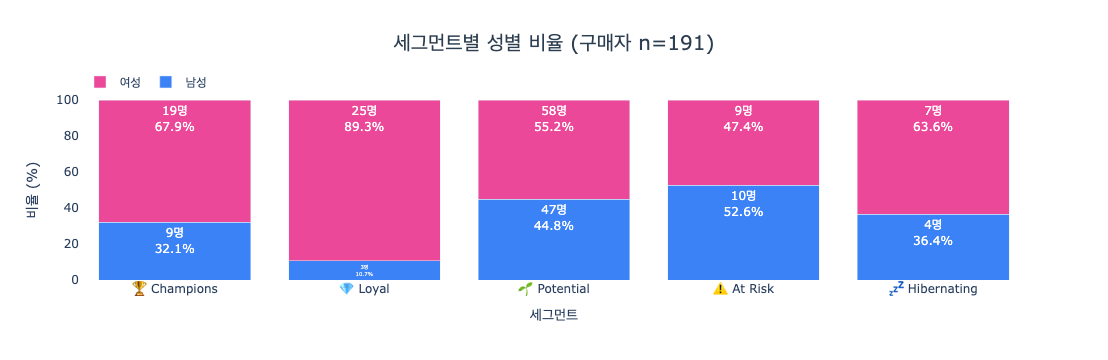

In [12]:
# 세그먼트별 성별 비율 — 스택 막대
gender_n = demo[['남성', '여성']]
gender_pct = gender_n.div(gender_n.sum(axis=1), axis=0).mul(100).round(1)

fig = go.Figure()
for gname, color in [('남성', '#3B82F6'), ('여성', '#EC4899')]:
    fig.add_trace(go.Bar(
        name=gname,
        x=[f"{SEGMENT_EMOJI[s]} {s}" for s in gender_pct.index],
        y=gender_pct[gname], marker_color=color,
        text=[f"{int(gender_n.loc[s, gname])}명<br>{gender_pct.loc[s, gname]:.1f}%" for s in gender_pct.index],
        textposition='inside', textfont=dict(color='white', size=12),
    ))
fig.update_layout(
    barmode='stack',
    title=dict(text=f'세그먼트별 성별 비율 (구매자 n={n_buyers})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='세그먼트', yaxis_title='비율 (%)', yaxis=dict(range=[0, 100]),
    plot_bgcolor='white', legend=dict(orientation='h', yanchor='bottom', y=1.02),
)
fig.show()

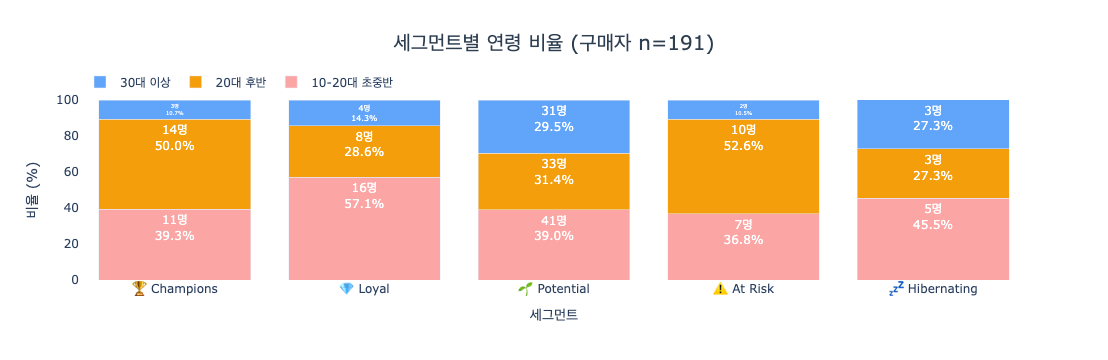

In [13]:
# 세그먼트별 연령 비율 — 스택 막대
age_pct = age_only.div(age_only.sum(axis=1), axis=0).mul(100).round(1)

fig = go.Figure()
for age_g in AGE3_ORDER:
    fig.add_trace(go.Bar(
        name=age_g,
        x=[f"{SEGMENT_EMOJI[s]} {s}" for s in age_pct.index],
        y=age_pct[age_g], marker_color=AGE_COLORS[age_g],
        text=[f"{int(age_only.loc[s, age_g])}명<br>{age_pct.loc[s, age_g]:.1f}%"
              if age_pct.loc[s, age_g] >= 5 else "" for s in age_pct.index],
        textposition='inside', textfont=dict(color='white', size=12),
    ))
fig.update_layout(
    barmode='stack',
    title=dict(text=f'세그먼트별 연령 비율 (구매자 n={n_buyers})', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='세그먼트', yaxis_title='비율 (%)', yaxis=dict(range=[0, 100]),
    plot_bgcolor='white', legend=dict(orientation='h', yanchor='bottom', y=1.02),
)
fig.show()

### 분석 질문 3 결과: 세그먼트 위계와 추천점수는 대체로 같은 방향
_사용 SQL: `segment_profile` (JOIN + PARTITION BY/OVER()) · `segment_gender` · `segment_age`_


> ### 섹션 결론
> - 표 기준으로 Champions와 Loyal은 평균 추천점수가 상대적으로 높고, Hibernating은 낮다. 즉 설문 기반 RFM 세그먼트와 추천 의향은 **대체로 같은 방향**으로 움직인다.
> - Loyal과 Champions의 주요 차이는 구매 빈도보다 **객단가(M)** 에서 나타난다. 두 그룹 모두 최근·고빈도 구매자지만, Champions는 객단가가 상대적으로 높은 신호를 보인다.
> - At Risk는 최근 구매 공백이 있으면서도 객단가 신호가 남아 있는 그룹이다. 다만 이를 확정 이탈자나 즉시 타겟으로 단정하지 않고, 섹션 5에서 **관찰 후보**로 한 번 더 점검한다.
> - 성별·연령 스택 막대는 세그먼트별 응답자 구성을 확인하기 위한 보조 프로파일이다. 표본 특성의 영향을 받을 수 있으므로, 타겟 확정이 아니라 세그먼트 이해를 돕는 참고 정보로 해석한다.


---

## 4. Potential 내부 세분화 — F × M 2×2
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? (F)
- Q11. 패션 플랫폼에서 한 번 구매할 때 평균 지출 금액은 얼마인가요? (M)

---

**분석 질문 4** — 가장 큰 Potential 그룹 안에서도 구매 빈도와 객단가 차이가 나타나는가?

- 분석 대상: Potential 세그먼트
- 분석 방법: SQL CTE로 F(1/2) × M(저/고) 2×2 사분면 라벨 부여 후 기술통계 비교
- 해석 기준: Potential을 단일 그룹으로 보는 것이 충분한지, 아니면 내부 이질성을 후속 분석 포인트로 남겨야 하는지 확인한다.
- 해석 흐름: 섹션 4와 5는 각각 가장 큰 구매자 그룹(Potential)과 구매 공백 그룹(At Risk)을 따로 살펴보는 보조 심화 분석이다.

**4사분면 정의**

| 사분면 | 정의 | 한 줄 풀이 | 해석 |
|---|---|---|---|
| **Active × High M** | F=2 AND M≥3 | 빈도와 객단가가 모두 중간 이상 | Champions에 가까워질 수 있는 후보 |
| **Active × Low M** | F=2 AND M<3 | 빈도는 중간, 객단가는 낮음 | 객단가 차이를 확인할 후보 |
| **Light × High M** | F=1 AND M≥3 | 빈도는 낮지만 객단가가 높음 | 구매 빈도 차이를 확인할 후보 |
| **Light × Low M** | F=1 AND M<3 | 빈도와 객단가가 모두 낮음 | 상대적으로 낮은 구매 활동 후보 |


In [14]:
# Potential 내부 F×M 세분화 (potential_split — CTE) + 프로파일 집계 (potential_profile)
df_potential = run('potential_split')
potential_summary = (
    run('potential_profile')
    .set_index('sub_segment').reindex(SUB_ORDER)
)
print(f'Potential: {len(df_potential)}명')
potential_summary

Potential: 105명


,n,avg_nps,avg_M,male_n,female_n,male_pct,female_pct
sub_segment,,,,,,,
Active × High M,27,6.85,3.26,15.0,12.0,55.6,44.4
Active × Low M,36,6.47,1.83,9.0,27.0,25.0,75.0
Light × High M,18,6.44,3.28,8.0,10.0,44.4,55.6
Light × Low M,24,5.46,1.83,15.0,9.0,62.5,37.5


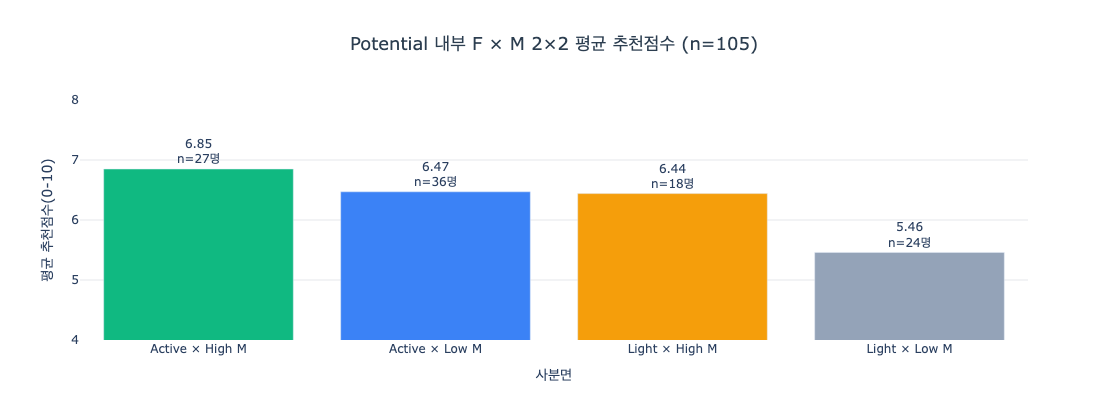

In [15]:
fig = go.Figure(go.Bar(
    x=SUB_ORDER,
    y=potential_summary['avg_nps'],
    marker_color=QUAD_COLORS,
    text=[f'{nps:.2f}<br>n={int(n)}명' for n, nps in
          zip(potential_summary['n'], potential_summary['avg_nps'])],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'Potential 내부 F × M 2×2 평균 추천점수 (n={len(df_potential)})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(title='사분면'),
    yaxis=dict(gridcolor='#e5e7eb', title='평균 추천점수(0-10)', range=[4, 8]),
    height=420, showlegend=False,
)
fig.show()

> Potential 내부 4사분면은 세부 표본이 더 작아지므로, 성별·연령 구성은 타겟팅 근거가 아니라 각 하위 그룹의 응답자 구성을 확인하는 보조 프로파일로만 해석한다.


### 분석 질문 4 결과: Potential 내부에도 F·M 조합별 차이가 존재
_사용 SQL: `potential_split` · `potential_profile` — CTE + GROUP BY_


> ### 섹션 결론
> - Potential 105명을 내부 F×M으로 나누면 평균 추천점수가 **5.46~6.85**로 최대 **1.39점** 차이 나고, 성별·연령 구성도 일부 다르다.
> - Active × High M은 Potential 안에서 상대적으로 높은 구매 활동 신호를 보이며, Light × Low M은 상대적으로 낮은 구매 활동 신호를 보인다.
> - 차트 안의 NPS 표기는 각 사분면의 태도 신호를 함께 보기 위한 보조 장치다. 다만 각 사분면의 표본은 더 작아지므로, 성별·연령 구성은 세부 타겟 확정보다 **Potential을 단일 그룹으로만 해석하면 놓칠 수 있는 내부 차이**로 보는 편이 안전하다.


---

## 5. At Risk 내부 객단가 신호 확인 — Can't Lose 후보
- Q9. 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? (F)
- Q10. 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? (R)
- Q11. 패션 플랫폼에서 한 번 구매할 때 평균 지출 금액은 얼마인가요? (M)
- Q1. 성별을 선택해주세요.
- Q2. 연령대를 선택해주세요.

---

**분석 질문 5** — At Risk 내부에서 객단가 신호가 남아 있는 후보는 어떤 구성인가?

- 정의: At Risk 세그먼트 중 M≥3(7만원 이상)
- 분석 방법: SQL `RANK() OVER`로 M과 추천점수 기준 우선순위 확인
- 정렬 기준: M을 1순위로 두고, 같은 M 안에서는 추천점수가 높은 응답자를 먼저 확인한다. 이는 확정 타겟 선정이 아니라, 객단가 신호와 태도 신호가 함께 남아 있는 후보를 훑어보기 위한 보조 정렬이다.
- 해석 기준: 이 그룹은 확정 이탈자나 즉시 타겟이 아니라, 구매 로그가 있다면 먼저 검증해볼 **관찰 후보**로 해석한다.

**`04_retention_and_behavior`와의 차이**
- `04_retention_and_behavior`의 `재활성화 후보`: 자주 구매했지만 3개월 초과 구매 공백이 있는 R×F 그룹
- `05_segmentation`의 `At Risk`: 3개월 초과 구매 공백이 있으면서 F 또는 M 신호가 남아 있는 R×F×M 그룹
- `05_segmentation`의 `Can't Lose 후보`: At Risk 안에서 객단가(M≥3)까지 높은 하위 후보

> **용어 사용 기준**: `Can't Lose`는 정통 RFM 용어를 그대로 확정 적용한 것이 아니라, At Risk 내부의 객단가 관찰 후보를 설명하기 위해 차용한 보조 라벨이다.

In [16]:
# Can't Lose 후보 (cant_lose — JOIN + RANK() OVER)
cant_lose = run('cant_lose')

# At Risk 전체 대비 비교 — At Risk 통계는 위 profile에서 가져온다
at_risk = profile[profile['rfm_segment'] == 'At Risk'].iloc[0]
summary = pd.DataFrame({
    'At Risk 전체': [
        int(at_risk['n']), at_risk['avg_nps'], at_risk['avg_R'], at_risk['avg_F'], at_risk['avg_M'],
    ],
    "Can't Lose 후보 (M≥3)": [
        len(cant_lose), round(cant_lose['nps'].mean(), 2),
        round(cant_lose['R'].mean(), 2), round(cant_lose['F'].mean(), 2), round(cant_lose['M'].mean(), 2),
    ],
}, index=['n', '평균 추천점수(0-10)', '평균 R', '평균 F', '평균 M'])
print(f"Can't Lose 후보: {len(cant_lose)}명 (At Risk 중 M≥3)")
summary

Can't Lose 후보: 15명 (At Risk 중 M≥3)


,At Risk 전체,Can't Lose 후보 (M≥3)
n,19.00,15.00
평균 추천점수(0-10),6.32,6.20
평균 R,1.79,1.73
평균 F,1.74,1.67
평균 M,3.16,3.53


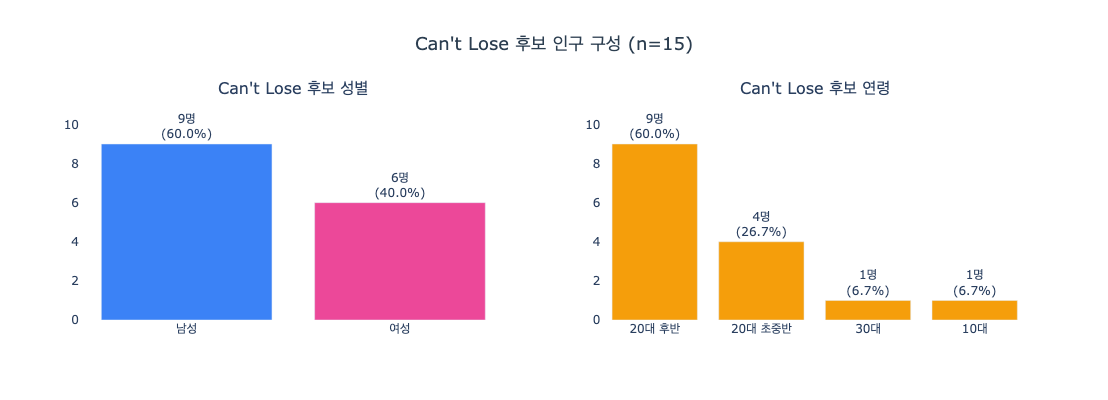

In [17]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Can't Lose 후보 성별", "Can't Lose 후보 연령"))

g = cant_lose['gender'].value_counts()
fig.add_trace(go.Bar(
    x=g.index, y=g.values,
    marker_color=['#3B82F6' if i == '남성' else '#EC4899' for i in g.index],
    text=[f"{int(v)}명<br>({v / len(cant_lose) * 100:.1f}%)" for v in g.values],
    textposition='outside', showlegend=False,
), row=1, col=1)

age_cl = cant_lose['age'].value_counts()
fig.add_trace(go.Bar(
    x=age_cl.index, y=age_cl.values, marker_color='#F59E0B',
    text=[f"{int(v)}명<br>({v / len(cant_lose) * 100:.1f}%)" for v in age_cl.values],
    textposition='outside', showlegend=False,
), row=1, col=2)

fig.update_yaxes(range=[0, g.values.max() * 1.25], row=1, col=1)
fig.update_yaxes(range=[0, age_cl.values.max() * 1.25], row=1, col=2)
fig.update_layout(
    title=dict(text=f"Can't Lose 후보 인구 구성 (n={len(cant_lose)})", x=0.5, xanchor='center',
               font=dict(size=18, color='#2c3e50')),
    plot_bgcolor='white', height=400,
)
fig.show()

> 표본 수가 작기 때문에 성별×연령 조합은 차이 해석이 아니라, Can't Lose 후보가 어떤 응답자 구성으로 이루어져 있는지 확인하는 보조 시각화로만 사용한다.


### 분석 질문 5 결과: At Risk 내부에서 객단가 신호가 남은 후보를 확인
_사용 SQL: `cant_lose` — JOIN + RANK() OVER_


> ### 섹션 결론
> - Can't Lose 후보 **15명**은 At Risk 내부에서 M≥3인 하위 그룹이다. 즉 최근 구매 공백이 있지만, 객단가 신호가 남아 있는 응답자다.
> - 이 그룹은 확정 이탈자나 즉시 CRM 타겟이 아니라, 실제 구매 로그가 있다면 먼저 확인해볼 관찰 후보에 가깝다.
> - 표본 수가 작기 때문에 성별·연령 조합은 패턴 해석이 아니라 후보 구성을 확인하는 보조 정보로만 해석한다.


---

## 결론 및 핵심 인사이트

`05_segmentation`는 `04_retention_and_behavior`의 R×F 구매 활동 상태 지도에 M(객단가)을 더해, 구매자 내부의 활동 강도와 객단가 신호를 더 세밀하게 확인한 노트북이다. 단, 이 분석은 거래 로그 기반의 정통 RFM 모델이 아니라 설문 응답을 점수화한 프로파일링이므로, 세그먼트는 확정 타겟이 아니라 **후속 검증 후보**로 해석한다.

---

### 통계/기술 분석 요약

| 섹션 | 분석 방법 | 결과 |
|------|---------|------|
| 분석 질문 1 — R·F·M 변수 분포 | 점수별 기술통계 | 세그먼트 분류 전 R·F·M 응답 분포와 희소 구간 확인 |
| 분석 질문 2 — 룰 기반 5세그먼트 분류 | SQL `CASE WHEN` | Potential이 가장 큰 단일 그룹이며, At Risk/Hibernating은 3개월 초과 구매 공백 축을 공유 |
| 분석 질문 3 — 세그먼트 프로파일링 | SQL 윈도우 함수 | 세그먼트 위계와 평균 추천점수는 대체로 같은 방향이며, 인구통계는 보조 프로파일로 확인 |
| 분석 질문 4 — Potential 내부 세분화 | SQL CTE + F×M 2×2 | Potential 내부에도 빈도·객단가 조합별 차이가 존재하며, NPS·성별·연령 구성은 후속 관찰 기준으로 활용 |
| 분석 질문 5 — At Risk 내부 객단가 신호 확인 | SQL `RANK() OVER` | At Risk 내부에서 객단가 신호가 남은 관찰 후보 확인 |

---

### 핵심 발견 요약

- **발견 1: R·F·M 변수는 세그먼트 분류 전 확인이 필요하다.** 설문 범주형 점수라 정통 RFM 분위 스코어링보다 룰 기반 분류가 적절하다.
- **발견 2: 구매자 내부에서 Potential이 가장 큰 그룹이다.** 최근 구매는 있으나 빈도가 낮은 사용자가 많아, 주요 차이는 단순 이탈보다 구매 빈도 성장 여지에 가깝다.
- **발견 3: 세그먼트와 추천점수는 대체로 같은 방향이다.** 다만 관계를 예측 모델이나 인과로 해석하지 않고, 태도-행동 프록시 정합성의 보조 근거로 본다.
- **발견 4: Potential은 단일 그룹으로만 보기엔 내부 차이가 있다.** F×M 2×2로 나누면 빈도와 객단가 조합별로 다른 신호가 나타나며, 평균 추천점수와 응답자 구성도 함께 확인할 수 있다.
- **발견 5: At Risk 내부에서 객단가 신호가 남은 후보를 확인했다.** 구매 공백이 있으면서 객단가 신호가 남은 응답자는 실제 로그로 먼저 확인해볼 관찰 후보가 된다.

---

> 발견별 상세 근거·해석은 각 섹션의 `섹션 결론`을, 통계 방법론은 [docs/METHODS.md](../docs/METHODS.md)를 참조한다.

---

✅ **A/B 테스트 제안**

섹션 4에서 Potential(105명)을 F×M 2×2로 나누면 하위 그룹 평균 추천점수가 **5.46~6.85**로 최대 **1.39점** 벌어졌다(하위 n=18~36). 즉 단일 그룹으로 보기엔 내부가 갈리지만, 설문으로는 이 차이가 실제 처리 반응 차이로 이어지는지 알 수 없어 인과는 실험으로만 확인된다.

- **가설**: Potential 내부 F×M 하위 그룹은 사분면 신호에 맞춘 메시지에 공통 메시지보다 다르게 반응하는가 (단일 처리 vs 차등 처리)?
- **설계**: 각 사분면 안에서 무작위 2군 — 실험군은 사분면 F×M 신호에 맞춘 차등 메시지, 대조군은 공통 메시지
- **1차 지표**: 일정 기간 내 재방문·재구매율, 보조로 클릭·찜·구매 금액
- **필요 데이터**: 사분면 라벨, 군 배정, 노출·클릭·방문·구매 로그
- **한계·확장**: 하위 표본이 작아 로그상 모수가 확보된 사분면부터 적용. 목표 수치는 `05_segmentation`에서 확정하지 않고 `04_retention_and_behavior` 후속 모니터링 지표 또는 서비스 전환율을 기준으로 둔다.

> 설문·단면 데이터 단계라 상세 실험 설계는 행동 로그 확보 후로 미루고, 여기서는 인과를 확인할 **방향성 후보**로만 제시한다 (확정 실행안 아님).  
> ⚠️ 사분면은 정의상 F·M이 다르므로 "그룹 정의 재진술"이 아니라 **차등 처리가 실제 반응 차이를 만드는지**를 보는 게 핵심.

✅ **후속 작업 제안**

- **Potential 내부 구성 확인**: F×M 4사분면별 성별·연령 구성과 평균 추천점수가 함께 움직이는지 후속 표본이나 로그 데이터로 확인한다. 이 단계에서는 타겟 확정보다 `어떤 하위 그룹을 더 관찰할지`를 정하는 데 초점을 둔다.
- **At Risk 객단가 신호 후보 확인**: At Risk 중 M≥3 후보는 최근 방문, 장바구니, 찜, 알림 반응 데이터를 먼저 확인해 실제 구매 공백 상태인지 검증한다. 반응 로그가 남아 있다면 재구매 유도 실험 후보로, 반응 로그가 거의 없다면 원인 파악용 인터뷰/텍스트 피드백 확인 후보로 분리한다.
- **`06_channel` 분석과 연결**: 플랫폼·유입 채널별로 RFM 세그먼트 구성이 달라지는지 확인해 채널별 후속 분석 질문으로 연결한다. 예를 들어 특정 채널에서 Potential 비중이 높다면 빈도 성장 실험 후보 채널로, At Risk 비중이 높다면 구매 공백 원인 확인 채널로 볼 수 있다.


---

### SQL 기법 매핑

이 노트북에서 각 분석을 산출한 SQL 쿼리와 기법(검정·다중응답·NLP는 pandas).

| 섹션 | SQL 쿼리 | 기법 |
|------|---------|------|
| 1 R·F·M 분포 | `rfm_distribution` | UNION ALL · GROUP BY · 윈도우 |
| 2 5세그먼트 분포 | `segment_counts` | GROUP BY · 윈도우 |
| 3 세그먼트 프로파일링 | `segment_profile` 외 | JOIN · PARTITION BY/OVER() |
| 4 Potential F×M | `potential_split`·`potential_profile` | CTE · GROUP BY |
| 5 Can't Lose | `cant_lose` | JOIN · RANK() OVER |
